<a href="https://colab.research.google.com/github/Bavesh-08/CIFAR-10-using-yolov8n/blob/main/CIFAR_10_using_yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install ultralytics torchvision pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 47.6 MB/s eta 0:00:00


In [ ]:
import os, random
from pathlib import Path

from torchvision import datasets

ROOT = Path("/content/cifar10_yolo")  # output dataset
USE_SUBSET = False                    # set False for full CIFAR-10 (slower)
TRAIN_N = 10000 if USE_SUBSET else 50000
VAL_N   = 2000  if USE_SUBSET else 5000  # we'll take from CIFAR10-train as validation

seed = 42
random.seed(seed)

# CIFAR-10
train_ds = datasets.CIFAR10(root="./data", train=True, download=True)  # returns PIL images
classes = train_ds.classes  # ['airplane', 'automobile', ...]
assert len(classes) == 10


for split in ["train", "val"]:
    for c in classes:
        (ROOT / split / c).mkdir(parents=True, exist_ok=True)

# Choose indices for train/val
all_indices = list(range(len(train_ds)))  # 50k
random.shuffle(all_indices)
val_indices = all_indices[:VAL_N]
train_indices = all_indices[VAL_N:VAL_N + TRAIN_N]

def save_images(indices, split):
    for k, idx in enumerate(indices):
        img, label = train_ds[idx]  # img is PIL Image
        img = img.convert("RGB")
        class_name = classes[label]
        out_path = ROOT / split / class_name / f"{split}_{idx:05d}.png"
        img.save(out_path)

        if (k + 1) % 1000 == 0:
            print(f"{split}: saved {k+1}/{len(indices)}")

print("Saving training images...")
save_images(train_indices, "train")

print("Saving validation images...")
save_images(val_indices, "val")

Saving training images...
train: saved 1000/45000
train: saved 2000/45000
train: saved 3000/45000
train: saved 4000/45000
train: saved 5000/45000
train: saved 6000/45000
train: saved 7000/45000
train: saved 8000/45000
train: saved 9000/45000
train: saved 10000/45000
train: saved 11000/45000
train: saved 12000/45000
train: saved 13000/45000
train: saved 14000/45000
train: saved 15000/45000
train: saved 16000/45000
train: saved 17000/45000
train: saved 18000/45000
train: saved 19000/45000
train: saved 20000/45000
train: saved 21000/45000
train: saved 22000/45000
train: saved 23000/45000
train: saved 24000/45000
train: saved 25000/45000
train: saved 26000/45000
train: saved 27000/45000
train: saved 28000/45000
train: saved 29000/45000
train: saved 30000/45000
train: saved 31000/45000
train: saved 32000/45000
train: saved 33000/45000
train: saved 34000/45000
train: saved 35000/45000
train: saved 36000/45000
train: saved 37000/45000
train: saved 38000/45000
train: saved 39000/45000
train: s

In [ ]:
import yaml
from pathlib import Path

yaml_path = Path("/content/cifar10_yolo/cifar10-cls.yaml")

data_yaml = {
    "path": str(ROOT),
    "train": "train",
    "val": "val",
    "names": classes
}

yaml_path.write_text(yaml.dump(data_yaml, sort_keys=False))
print("Wrote:", yaml_path)

Wrote: /content/cifar10_yolo/cifar10-cls.yaml


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n-cls.pt")  # small + fast

results = model.train(
    data=str(ROOT),
    epochs=5,       # increase if you want better accuracy
    imgsz=32,       # CIFAR-10 is 32x32
    batch=64,
    workers=2
)

Ultralytics 8.4.35 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cifar10_yolo, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=32, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

In [ ]:
metrics = model.val(data=str(yaml_path), imgsz=32)
print(metrics)

Ultralytics 8.4.35 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 140.5±50.6 MB/s, size: 2.1 KB)
val: Scanning /content/cifar10_yolo/val... 5000 images, 0 corrupt: 100% ━━━━━━━━━━━━ 5000/5000 1.4Git/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 313/313 69.6it/s 4.5s
                   all      0.753      0.985
Speed: 0.0ms preprocess, 0.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val3
ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7955643ed070>
curves: []
curves_results: []
fitness: 0.8686999976634979
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.7527999877929688, 'metrics/accuracy_top5': 0.9846000075340271, 'fitness': 0.8686999976634979}
save_dir: PosixPath('/content/runs/classify/val3')
speed: {'prep

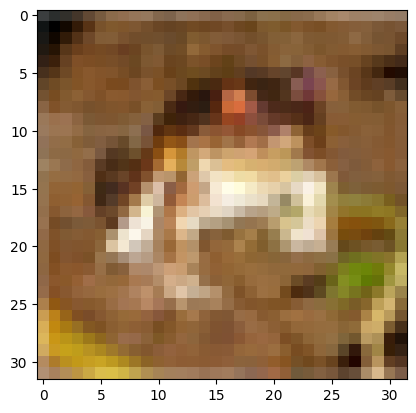

In [ ]:
import matplotlib.pyplot as plt

image, label = train_ds[0] # Unpack the tuple
plt.imshow(image)
plt.show()

In [ ]:
model.names

{0: 'airplane',
 1: 'automobile',
 2: 'bird',
 3: 'cat',
 4: 'deer',
 5: 'dog',
 6: 'frog',
 7: 'horse',
 8: 'ship',
 9: 'truck'}